# Signal and Array Creation Demo

This notebook demonstrates how to create signals and array configurations using the SubspaceNet library.

## Features:
- **Configurable System Parameters**: Set number of sources, sensors, observations, etc.
- **Flexible Signal Generation**: Create narrowband or broadband signals with customizable properties
- **Array Configuration**: Define uniform linear arrays with various geometries
- **DOA Specification**: Set direction of arrival angles manually or auto-generate

---


In [1]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
# Enable interactive matplotlib backend for Jupyter notebooks
%matplotlib widget

# Add the SubspaceNet src directory to Python path
sys.path.append('../../SubspaceNet/src')

# Import modules using absolute imports to avoid relative import issues
from system_model import SystemModel, SystemModelParams
from signal_creation import Samples

# # Create aliases for easier access
# SystemModel = system_model.SystemModel
# SystemModelParams = system_model.SystemModelParams
# Samples = signal_creation.Samples

# Set up matplotlib for better plots
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

print("✅ Imports successful! Ready to create signals and arrays...")


ModuleNotFoundError: No module named 'src'

## 1. Configure System Parameters

Set the basic parameters for your signal and array system:


In [ ]:
# System Configuration Parameters
# ================================

# Basic system parameters
M = 2                           # Number of sources
N = 8                           # Number of sensors
T = 1024                         # Number of observations (time samples)

# Signal type and properties
signal_type = "NarrowBand"       # Options: "NarrowBand" or "Broadband"
signal_nature = "non-coherent"   # Options: "non-coherent" or "coherent"
snr = 5                        # Signal-to-noise ratio in dB

# Broadband signal parameters (only used if signal_type = "Broadband")
freq_values = [100, 500]        # [min_freq, max_freq] in Hz

# Array imperfections (set to 0 for ideal array)
eta = 0                         # Sensor location deviation
bias = 0                        # Sensor bias deviation  
sv_noise_var = 0                # Steering vector noise variance

print(f"📊 System Configuration:")
print(f"   Sources: {M}, Sensors: {N}, Observations: {T}")
print(f"   Signal Type: {signal_type}")
print(f"   Signal Nature: {signal_nature}")
print(f"   SNR: {snr} dB")
if signal_type == "Broadband":
    print(f"   Frequency Range: {freq_values[0]}-{freq_values[1]} Hz")


📊 System Configuration:
   Sources: 2, Sensors: 8, Observations: 1024
   Signal Type: NarrowBand
   Signal Nature: non-coherent
   SNR: 5 dB


## 2. Create System Model and Array

Initialize the system model with your parameters:


In [ ]:
# Create system model parameters object
params = SystemModelParams()
params.set_parameter("M", 2)
params.set_parameter("N", 8)
params.set_parameter("T", 1024)
params.set_parameter("signal_type", "NarrowBand")
params.set_parameter("signal_nature", "non-coherent")
params.set_parameter("snr", 10)
params.set_parameter("eta", 0)

# Create the samples object (includes system model)
samples_obj = Samples(params)

print("✅ System model created successfully!")
print(f"📡 Array configuration:")
print(f"   Array positions: {samples_obj.array}")
print(f"   Element spacing: {samples_obj.dist[signal_type]:.3f} wavelengths")
angle_example = 90
steering_vector = samples_obj.steering_vec(angle_example, nominal=True)
steering_vector_norm = np.linalg.norm(steering_vector)
print(steering_vector_norm)
print(steering_vector.shape)

✅ System model created successfully!
📡 Array configuration:
   Array positions: [0. 1. 2. 3. 4. 5. 6. 7.]
   Element spacing: 0.500 wavelengths
0.9999999999999999
(8,)


## 3. Set Direction of Arrival (DOA) Angles

Define the angles from which signals arrive:


In [ ]:
# DOA Configuration
# =================

# Option 1: Specify exact DOA angles in degrees
doa_angles = [0, 5]  # Angles in degrees, set to None for auto-generation

# Option 2: Auto-generate DOAs with minimum separation (set doa_angles = None)
# doa_angles = None  # This will auto-generate angles with 15° minimum separation

# Set the DOA angles
samples_obj.set_doa(doa_angles)

# Convert back to degrees for display
doa_degrees = np.rad2deg(samples_obj.doa)

print(f"🎯 Direction of Arrival angles set:")
for i, angle in enumerate(doa_degrees):
    print(f"   Source {i+1}: {angle:.1f}°")


🎯 Direction of Arrival angles set:
   Source 1: 0.0°
   Source 2: 5.0°


## 4. Generate Signals and Observations

Create the actual signals and array observations:


In [ ]:
# Signal Generation Parameters
# ============================

# Noise parameters
noise_mean = 0
noise_variance = 1

# Signal parameters
signal_mean = 0
signal_variance = 1

# Generate samples
observations, signals, steering_vectors, noise = samples_obj.samples_creation(
    noise_mean=noise_mean,
    noise_variance=noise_variance, 
    signal_mean=signal_mean,
    signal_variance=signal_variance
)

print("🔊 Signals generated successfully!")
print(f"📊 Data shapes:")
print(f"   Observations: {observations.shape} (sensors x time)")
print(f"   Signals: {signals.shape} (sources x time)")
print(f"   Steering vectors: {steering_vectors.shape} (sensors x sources)")
print(f"   Noise: {noise.shape} (sensors x time)")


🔊 Signals generated successfully!
📊 Data shapes:
   Observations: (8, 1024) (sensors x time)
   Signals: (2, 1024) (sources x time)
   Steering vectors: (8, 2) (sensors x sources)
   Noise: (8, 1024) (sensors x time)


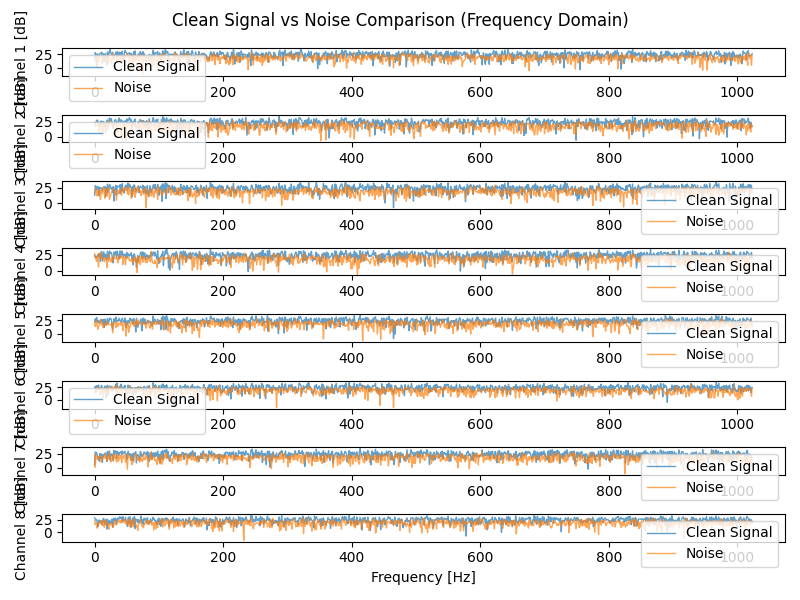

In [ ]:
# Create figure with subplots for each channel
fig, axes = plt.subplots(noise.shape[0], 1, figsize=(8, 6))
fig.suptitle('Clean Signal vs Noise Comparison (Frequency Domain)')

# Plot each channel
for i in range(noise.shape[0]):
    # Compute FFT for clean signal and noise
    clean_fft = np.fft.fftshift(np.fft.fft(observations[i]))
    noise_fft = np.fft.fftshift(np.fft.fft(noise[i]))
    
    # Create frequency axis
    # freq = np.fft.fftshift(np.fft.fftfreq(len(signals[i]), 1/signal_config.fs))
    
    # Plot magnitude spectrum in dB
    clean_magnitude_db = 20 * np.log10(np.abs(clean_fft) + 1e-12)
    noise_magnitude_db = 20 * np.log10(np.abs(noise_fft) + 1e-12)
    
    # Plot clean signal
    axes[i].plot(clean_magnitude_db, label='Clean Signal', alpha=0.7, linewidth=1)
    # Plot noise
    axes[i].plot(noise_magnitude_db, label='Noise', alpha=0.7, linewidth=1)
    axes[i].set_ylabel(f'Channel {i+1} [dB]')
    axes[i].legend()
    if i == noise.shape[0]-1:  # Only show xlabel for bottom subplot
        axes[i].set_xlabel('Frequency [Hz]')

plt.tight_layout()
plt.show()


## 5. Visualize Results

Plot the generated signals and array configuration:


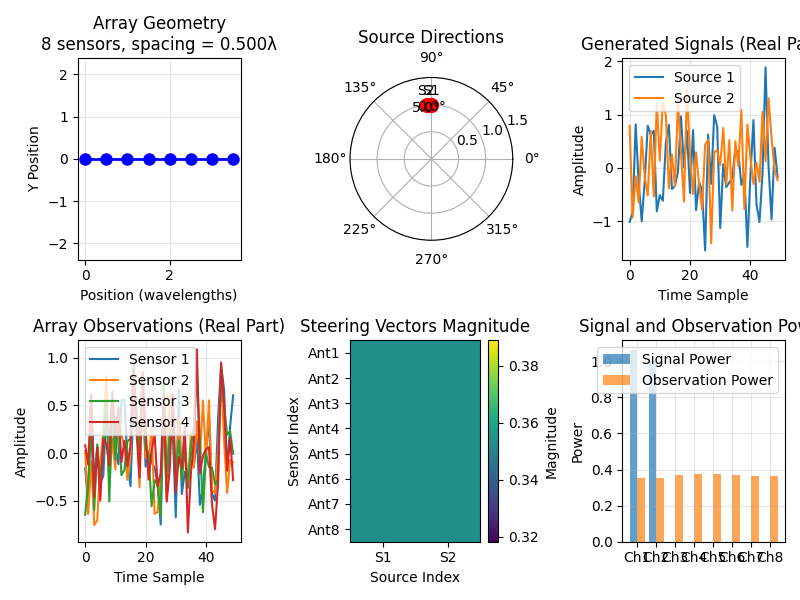

📈 Visualization complete!


In [ ]:
# Create visualization
fig = plt.figure(figsize=(8, 6))

# 1. Array geometry
plt.subplot(2, 3, 1)
plt.plot(samples_obj.array * samples_obj.dist[signal_type], np.zeros(N), 'bo-', markersize=8, linewidth=2)
plt.xlabel('Position (wavelengths)')
plt.ylabel('Y Position')
plt.title(f'Array Geometry\n{N} sensors, spacing = {samples_obj.dist[signal_type]:.3f}λ')
plt.grid(True, alpha=0.3)
plt.axis('equal')

# 2. DOA visualization
plt.subplot(2, 3, 2, projection='polar')
angles_rad = np.deg2rad(doa_degrees + 90)  # Convert to polar coordinates
plt.plot(angles_rad, np.ones(len(angles_rad)), 'ro', markersize=10)
for i, (angle, angle_deg) in enumerate(zip(angles_rad, doa_degrees)):
    plt.annotate(f'S{i+1}\n{angle_deg:.1f}°', (angle, 1.1), ha='center', va='center')
plt.ylim(0, 1.5)
plt.title('Source Directions')

# 3. Original signals (real part)
plt.subplot(2, 3, 3)
time_axis = np.arange(min(T, 50))  # Show first 50 samples
for i in range(M):
    plt.plot(time_axis, np.real(signals[i, :len(time_axis)]), label=f'Source {i+1}')
plt.xlabel('Time Sample')
plt.ylabel('Amplitude')
plt.title('Generated Signals (Real Part)')
plt.legend()
plt.grid(True, alpha=0.3)

# 4. Array observations (real part)
plt.subplot(2, 3, 4)
for i in range(min(N, 4)):  # Show first 4 sensors
    plt.plot(time_axis, np.real(observations[i, :len(time_axis)]), label=f'Sensor {i+1}')
plt.xlabel('Time Sample')
plt.ylabel('Amplitude')
plt.title('Array Observations (Real Part)')
plt.legend()
plt.grid(True, alpha=0.3)

# 5. Steering vectors magnitude
plt.subplot(2, 3, 5)
im = plt.imshow(np.abs(steering_vectors), aspect='auto', cmap='viridis')
plt.colorbar(im, label='Magnitude')
plt.xlabel('Source Index')
plt.ylabel('Sensor Index')
plt.title('Steering Vectors Magnitude')
plt.xticks(range(M), [f'S{i+1}' for i in range(M)])
plt.yticks(range(N), [f'Ant{i+1}' for i in range(N)])

# 6. Signal power vs noise power
plt.subplot(2, 3, 6)
signal_power = np.mean(np.abs(signals)**2, axis=1)
noise_power = np.mean(np.abs(noise)**2, axis=0)
obs_power = np.mean(np.abs(observations)**2, axis=1)

x_pos = np.arange(max(M, N))
if M <= N:
    plt.bar(x_pos[:M], signal_power, alpha=0.7, label='Signal Power', width=0.4)
    plt.bar(x_pos[:N] + 0.4, obs_power, alpha=0.7, label='Observation Power', width=0.4)
    plt.xticks(x_pos[:max(M,N)] + 0.2, [f'Ch{i+1}' for i in range(max(M,N))])
else:
    plt.bar(x_pos[:M], signal_power, alpha=0.7, label='Signal Power', width=0.4)
    plt.bar(x_pos[:N] + 0.4, obs_power, alpha=0.7, label='Observation Power', width=0.4)
    plt.xticks(x_pos + 0.2, [f'Ch{i+1}' for i in range(max(M,N))])

plt.ylabel('Power')
plt.title('Signal and Observation Power')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("📈 Visualization complete!")


## 6. DOA Estimation with Classical Algorithms

Now let's apply classical DOA estimation algorithms (MUSIC and MVDR) to our generated data:


In [ ]:
# Import DOA estimation methods
from methods import MUSIC, MVDR, RootMUSIC
import scipy.signal

# Create algorithm instances using our system model
music_estimator = MUSIC(samples_obj)
mvdr_estimator = MVDR(samples_obj)
rootmusic_estimator = RootMUSIC(samples_obj)

print("🎵 MUSIC and MVDR estimators initialized successfully!")


🎵 MUSIC and MVDR estimators initialized successfully!


In [ ]:
# Apply MUSIC Algorithm
# =====================

if signal_type == "NarrowBand":
    # Run MUSIC estimation
    music_predictions, music_spectrum, estimated_M = music_estimator.narrowband(
        X=observations,
        known_num_of_sources=True,
        mode="sample"
    )
    
    print(f"🎯 MUSIC Results:")
    print(f"   True DOAs: {doa_degrees}")
    print(f"   MUSIC Estimates: {music_predictions}")
    print(f"   Estimation Errors: {np.abs(np.sort(doa_degrees) - np.sort(music_predictions))}")
    
else:
    # For broadband signals, use broadband MUSIC
    music_predictions, music_spectrum, estimated_M = music_estimator.broadband(
        X=observations,
        known_num_of_sources=True
    )
    
    print(f"🎯 Broadband MUSIC Results:")
    print(f"   True DOAs: {doa_degrees}")
    print(f"   MUSIC Estimates: {music_predictions}")
    print(f"   Estimation Errors: {np.abs(np.sort(doa_degrees) - np.sort(music_predictions))}")

print(f"   Number of sources detected: {estimated_M}")


🎯 MUSIC Results:
   True DOAs: [0. 5.]
   MUSIC Estimates: [0. 5.]
   Estimation Errors: [0.00000000e+00 7.10542736e-15]
   Number of sources detected: 2


In [ ]:
# Apply MVDR Algorithm
# ====================

if signal_type == "NarrowBand":
    # Run MVDR estimation  
    mvdr_predictions, mvdr_response = mvdr_estimator.narrowband(
        X=observations,
        mode="sample",
        eps=0.01  # Diagonal loading factor
    )
    
    # Find peaks in MVDR response for DOA estimation
    mvdr_response_real = np.real(mvdr_response)
    peaks, _ = scipy.signal.find_peaks(mvdr_response_real)
    
    # Sort peaks by amplitude and take the top M
    peak_amplitudes = mvdr_response_real[peaks]
    sorted_peak_indices = np.argsort(peak_amplitudes)[::-1]  # Descending order
    top_peaks = peaks[sorted_peak_indices[:M]]
    
    # Convert peak indices to angles
    angle_grid = np.rad2deg(music_estimator._angels)
    mvdr_estimated_angles = angle_grid[top_peaks]
    
    print(f"🌊 MVDR Results:")
    print(f"   True DOAs: {doa_degrees}")
    print(f"   MVDR Estimates: {mvdr_estimated_angles}")
    print(f"   Estimation Errors: {np.abs(np.sort(doa_degrees) - np.sort(mvdr_estimated_angles))}")
    
else:
    print("⚠️  MVDR broadband implementation not available in current version")
    mvdr_response = None
    mvdr_estimated_angles = None


🌊 MVDR Results:
   True DOAs: [0. 5.]
   MVDR Estimates: [  2. -25.]
   Estimation Errors: [25.  3.]


In [ ]:
# Apply RootMUSIC Algorithm
# =========================

if signal_type == "NarrowBand":
    # Run RootMUSIC estimation  
    rootmusic_predictions, rootmusic_spectrum, rootmusic_predictions_all, rootmusic_spectrum_all, M = rootmusic_estimator.narrowband(
        X=observations,
        mode="sample"
    )
    
    print(f"🎯 RootMUSIC Results:")
    print(f"   True DOAs: {doa_degrees}")
    print(f"   RootMUSIC Estimates: {rootmusic_predictions}")
    print(f"   Estimation Errors: {np.abs(np.sort(doa_degrees) - np.sort(rootmusic_predictions))}")
    
else:
    print("⚠️  RootMUSIC broadband implementation not available in current version")
    rootmusic_spectrum = None
    rootmusic_predictions = None


🎯 RootMUSIC Results:
   True DOAs: [0. 5.]
   RootMUSIC Estimates: [ 5.20697863 -0.047269  ]
   Estimation Errors: [0.047269   0.20697863]


## 7. Visualize DOA Estimation Results

Compare the true DOA angles with algorithm estimates:


🎯 MUSIC Errors: [0.0, 7.105427357601002e-15]


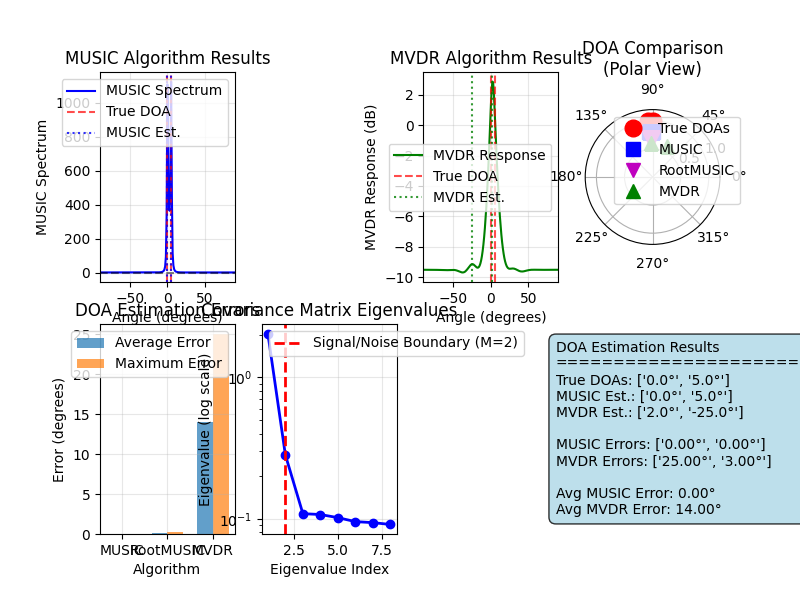

📊 DOA estimation visualization complete!


In [ ]:
# Create DOA estimation results visualization
fig = plt.figure(figsize=(8, 6))

if signal_type == "NarrowBand":
    # Convert angle grid to degrees for plotting
    angle_grid_deg = np.rad2deg(music_estimator._angels)
    
    # 1. MUSIC Spectrum
    plt.subplot(2, 4, 1)
    plt.plot(angle_grid_deg, np.real(music_spectrum), 'b-', linewidth=1.5, label='MUSIC Spectrum')
    plt.axhline(y=0, color='k', linestyle='--', alpha=0.5)
    
    # Mark true DOAs
    for i, true_angle in enumerate(doa_degrees):
        plt.axvline(x=true_angle, color='red', linestyle='--', alpha=0.7, label='True DOA' if i == 0 else '')
    
    # Mark MUSIC estimates
    for i, est_angle in enumerate(music_predictions):
        plt.axvline(x=est_angle, color='blue', linestyle=':', alpha=0.8, label='MUSIC Est.' if i == 0 else '')
    
    plt.xlabel('Angle (degrees)')
    plt.ylabel('MUSIC Spectrum')
    plt.title('MUSIC Algorithm Results')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xlim([-90, 90])
    
    # 2. RootMUSIC Spectrum
    # if rootmusic_spectrum is not None:
    #     plt.subplot(2, 4, 2, projection='polar')
    #     # Set axis location and limits
    #     plt.set_theta_zero_location('N')
    #     plt.set_theta_direction(-1)
    #     plt.set_thetamin(90)
    #     plt.set_thetamax(-90)
    #     # plot roots ang angles 
    #     for i in range(len(rootmusic_predictions)):
    #         angle = rootmusic_predictions[i]
    #     r = np.abs(rootmusic_predictions_all[i])
    #     plt.set_ylim([0, 1.2])
    #     plt.set_yticks([0, 1])
    #     plt.plot([0, angle * np.pi / 180], [0, r], marker='o')
    #     for doa in doa_degrees:
    #         plt.plot([doa * np.pi / 180], [1], marker='x', color="r", markersize=14)
    #     plt.set_xlabel("Angels [deg]")
    #     plt.set_ylabel("Amplitude")
        
    #     # For RootMUSIC, plot the polynomial roots on unit circle
    #     plt.plot(angle_grid_deg, np.real(rootmusic_spectrum), 'm-', linewidth=1.5, label='RootMUSIC Spectrum')
    #     plt.axhline(y=0, color='k', linestyle='--', alpha=0.5)
        
    #     # Mark true DOAs
    #     for i, true_angle in enumerate(doa_degrees):
    #         plt.axvline(x=true_angle, color='red', linestyle='--', alpha=0.7, label='True DOA' if i == 0 else '')
        
    #     # Mark RootMUSIC estimates
    #     for i, est_angle in enumerate(rootmusic_predictions):
    #         plt.axvline(x=est_angle, color='magenta', linestyle=':', alpha=0.8, label='RootMUSIC Est.' if i == 0 else '')
        
    #     plt.xlabel('Angle (degrees)')
    #     plt.ylabel('RootMUSIC Spectrum')
    #     plt.title('RootMUSIC Algorithm Results')
    #     plt.legend()
    #     plt.grid(True, alpha=0.3)
    #     plt.xlim([-90, 90])
    
    # 3. MVDR Response
    if mvdr_response is not None:
        plt.subplot(2, 4, 3)
        mvdr_response_db = 10 * np.log10(np.real(mvdr_response) + 1e-10)
        plt.plot(angle_grid_deg, mvdr_response_db, 'g-', linewidth=1.5, label='MVDR Response')
        
        # Mark true DOAs
        for i, true_angle in enumerate(doa_degrees):
            plt.axvline(x=true_angle, color='red', linestyle='--', alpha=0.7, label='True DOA' if i == 0 else '')
        
        # Mark MVDR estimates
        for i, est_angle in enumerate(mvdr_estimated_angles):
            plt.axvline(x=est_angle, color='green', linestyle=':', alpha=0.8, label='MVDR Est.' if i == 0 else '')
        
        plt.xlabel('Angle (degrees)')
        plt.ylabel('MVDR Response (dB)')
        plt.title('MVDR Algorithm Results')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.xlim([-90, 90])
    
    # 4. Comparison polar plot
    plt.subplot(2, 4, 4, projection='polar')
    
    # True DOAs
    true_angles_rad = np.deg2rad(doa_degrees + 90)
    plt.plot(true_angles_rad, np.ones(len(true_angles_rad)), 'ro', markersize=12, label='True DOAs')
    
    # MUSIC estimates
    music_angles_rad = np.deg2rad(music_predictions + 90)
    plt.plot(music_angles_rad, 0.8 * np.ones(len(music_angles_rad)), 'bs', markersize=10, label='MUSIC')
    
    # RootMUSIC estimates (if available)
    if rootmusic_spectrum is not None:
        rootmusic_angles_rad = np.deg2rad(rootmusic_predictions + 90)
        plt.plot(rootmusic_angles_rad, 0.7 * np.ones(len(rootmusic_angles_rad)), 'mv', markersize=10, label='RootMUSIC')
    
    # MVDR estimates (if available)
    if mvdr_response is not None:
        mvdr_angles_rad = np.deg2rad(mvdr_estimated_angles + 90)
        plt.plot(mvdr_angles_rad, 0.6 * np.ones(len(mvdr_angles_rad)), 'g^', markersize=10, label='MVDR')
    
    plt.ylim(0, 1.2)
    plt.title('DOA Comparison\n(Polar View)')
    plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1.0))
    
    # 5. Estimation errors
    plt.subplot(2, 4, 5)
    
    # Calculate errors (minimum distance matching)
    music_errors = []
    for true_angle in doa_degrees:
        min_error = min([abs(true_angle - est) for est in music_predictions])
        music_errors.append(min_error)
        
    # Find best permutation match
    min_error = float('inf')
    from itertools import permutations
    
    for perm in permutations(music_predictions):
        perm_array = np.array(perm)
        if not np.any(np.isnan(perm_array)):
            error = np.abs(doa_degrees - perm_array)
            if np.linalg.norm(error) < np.linalg.norm(min_error):
                min_error = error

    music_errors = min_error.tolist()
    print(f"🎯 MUSIC Errors: {music_errors}")

    
    algorithms = ['MUSIC']
    avg_errors = [np.mean(music_errors)]
    max_errors = [np.max(music_errors)]
    
    # RootMUSIC errors
    if rootmusic_spectrum is not None:
        min_error = float('inf')
        for perm in permutations(rootmusic_predictions):
            perm_array = np.array(perm)
            if not np.any(np.isnan(perm_array)):
                error = np.abs(doa_degrees - perm_array)
                if np.linalg.norm(error) < np.linalg.norm(min_error):
                    min_error = error
        rootmusic_errors = min_error.tolist()
        algorithms.append('RootMUSIC')
        avg_errors.append(np.mean(rootmusic_errors))
        max_errors.append(np.max(rootmusic_errors))
    
    min_error = float('inf')
    if mvdr_response is not None:
        mvdr_errors = []
        for perm in permutations(mvdr_estimated_angles):
            perm_array = np.array(perm)
            if not np.any(np.isnan(perm_array)):
                error = np.abs(doa_degrees - perm_array)
                if np.linalg.norm(error) < np.linalg.norm(min_error):
                    min_error = error
        mvdr_errors = min_error.tolist()
        algorithms.append('MVDR')
        avg_errors.append(np.mean(mvdr_errors))
        max_errors.append(np.max(mvdr_errors))
    
    x_pos = np.arange(len(algorithms))
    width = 0.35
    
    plt.bar(x_pos - width/2, avg_errors, width, label='Average Error', alpha=0.7)
    plt.bar(x_pos + width/2, max_errors, width, label='Maximum Error', alpha=0.7)
    
    plt.xlabel('Algorithm')
    plt.ylabel('Error (degrees)')
    plt.title('DOA Estimation Errors')
    plt.xticks(x_pos, algorithms)
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # 6. Signal vs Noise subspace
    plt.subplot(2, 4, 6)
    
    # Calculate covariance matrix for eigenvalue analysis
    R = np.cov(observations)
    eigenvals, eigenvecs = np.linalg.eigh(R)
    eigenvals = np.real(eigenvals)
    eigenvals_sorted = np.sort(eigenvals)[::-1]  # Descending order
    
    plt.semilogy(range(1, len(eigenvals_sorted) + 1), eigenvals_sorted, 'bo-', linewidth=2, markersize=6)
    plt.axvline(x=M, color='red', linestyle='--', linewidth=2, label=f'Signal/Noise Boundary (M={M})')
    
    plt.xlabel('Eigenvalue Index')
    plt.ylabel('Eigenvalue (log scale)')
    plt.title('Covariance Matrix Eigenvalues')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # 6. Estimation results summary
    plt.subplot(2, 3, 6)
    plt.axis('off')
    
    # Create text summary
    summary_text = "DOA Estimation Results\n" + "="*25 + "\n"
    summary_text += f"True DOAs: {[f'{angle:.1f}°' for angle in doa_degrees]}\n"
    summary_text += f"MUSIC Est.: {[f'{angle:.1f}°' for angle in music_predictions]}\n"
    
    if mvdr_response is not None:
        summary_text += f"MVDR Est.: {[f'{angle:.1f}°' for angle in mvdr_estimated_angles]}\n"
    
    summary_text += f"\nMUSIC Errors: {[f'{error:.2f}°' for error in music_errors]}\n"
    
    if mvdr_response is not None:
        summary_text += f"MVDR Errors: {[f'{error:.2f}°' for error in mvdr_errors]}\n"
    
    summary_text += f"\nAvg MUSIC Error: {np.mean(music_errors):.2f}°\n"
    
    if mvdr_response is not None:
        summary_text += f"Avg MVDR Error: {np.mean(mvdr_errors):.2f}°"
    
    plt.text(0.1, 0.5, summary_text, fontsize=10, verticalalignment='center',
             bbox=dict(boxstyle="round,pad=0.5", facecolor="lightblue", alpha=0.8))
    
else:
    # For broadband signals
    plt.subplot(1, 2, 1)
    # Simple comparison for broadband
    source_indices = range(1, len(doa_degrees) + 1)
    width = 0.35
    x_pos = np.arange(len(source_indices))
    
    plt.bar(x_pos - width/2, doa_degrees, width, label='True DOAs', alpha=0.7, color='red')
    plt.bar(x_pos + width/2, music_predictions, width, label='MUSIC Est.', alpha=0.7, color='blue')
    
    plt.xlabel('Source Index')
    plt.ylabel('DOA (degrees)')
    plt.title('Broadband MUSIC Results')
    plt.xticks(x_pos, source_indices)
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.subplot(1, 2, 2)
    # Error analysis
    errors = np.abs(np.array(doa_degrees) - np.array(music_predictions))
    plt.bar(source_indices, errors, alpha=0.7, color='orange')
    plt.xlabel('Source Index')
    plt.ylabel('Estimation Error (degrees)')
    plt.title('MUSIC Estimation Errors')
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("📊 DOA estimation visualization complete!")


RootMUSIC predictions: [ 5.20697863 -0.047269  ]


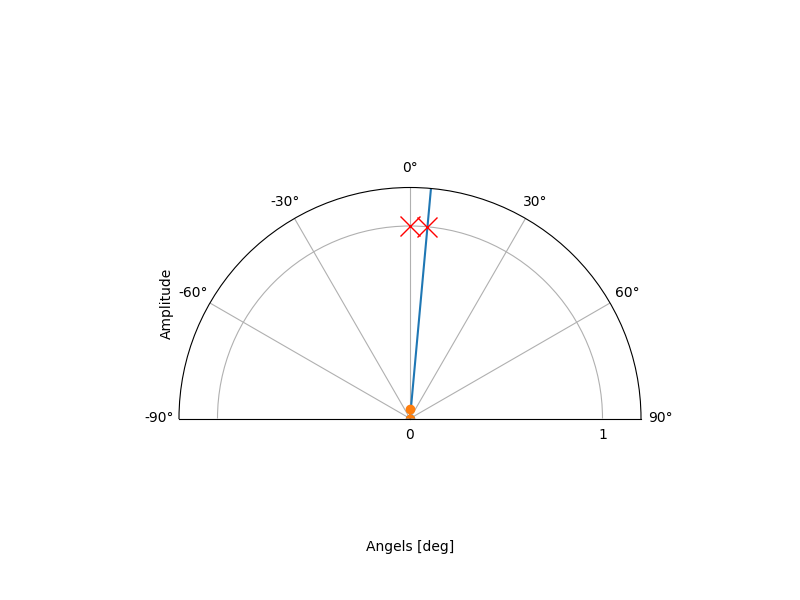

In [ ]:
# Initialize figure
print(f'RootMUSIC predictions: {rootmusic_predictions}')
plt.style.use('default')
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, polar=True)
# Set axis location and limits
ax.set_theta_zero_location('N')
ax.set_theta_direction(-1)
ax.set_thetamin(90)
ax.set_thetamax(-90)
# plot roots ang angles 
for i in range(len(rootmusic_predictions)):
    angle = rootmusic_predictions[i]
    r = np.abs(rootmusic_predictions_all[i])
    ax.set_ylim([0, 1.2])
    ax.set_yticks([0, 1])
    ax.plot([0, angle * np.pi / 180], [0, r], marker='o')
for doa in doa_degrees:
    ax.plot([doa * np.pi / 180], [1], marker='x', color="r", markersize=14)
ax.set_xlabel("Angels [deg]")
ax.set_ylabel("Amplitude")
plt.show()

In [ ]:
import sys
sys.path.append('../src')

import numpy as np
import matplotlib.pyplot as plt
import torch
from pathlib import Path
import json
from typing import List, Dict, Tuple
import warnings
warnings.filterwarnings('ignore')

# Tri4Net imports ONLY
from signalgen.array_processing import ArrayConfig, ArrayModel
from signalgen.signal_generator import SignalConfig, SignalGenerator
from data.dataset_generator import SimpleDatasetConfig, ControlledDatasetGenerator, DOADataset



print("All Tri4Net imports successful!")


All Tri4Net imports successful!


In [ ]:
# ULA configuration using Tri4Net ArrayConfig
ula_config = ArrayConfig(
    array_type='linear',
    num_elements=8,
    element_spacing=0.5,  # λ/2 spacing
    carrier_freq=2.45e9,
    enable_gain_phase_errors=False,  # Start with perfect array
    enable_mutual_coupling=False
)

# Create ULA array model
ula_array = ArrayModel(ula_config, seed=42)
# Define ULA-appropriate angle range
ula_angles = np.linspace(0, 180, 180)  # -90 to +90 degrees, 1-degree resolution
print(f"\nAngle range: {ula_angles[0]}° to {ula_angles[-1]}° ({len(ula_angles)} points)")
A = ula_array.steering_matrix(ula_angles, nominal=False)
A_nominal = ula_array.steering_matrix(ula_angles, nominal=True)


Angle range: 0.0° to 180.0° (180 points)


In [ ]:
print('Trace of the covariance matrix: ', np.trace(R))

Trace of the covariance matrix:  (2.9243229444885603-2.9890283818500315e-19j)


Are array_manifold_mine and array_manifold equal?
Shape comparison:
array_manifold_mine shape: (8, 180)
array_manifold shape: (8, 180)
Shapes are equal: True
Values are equal (within tolerance): True


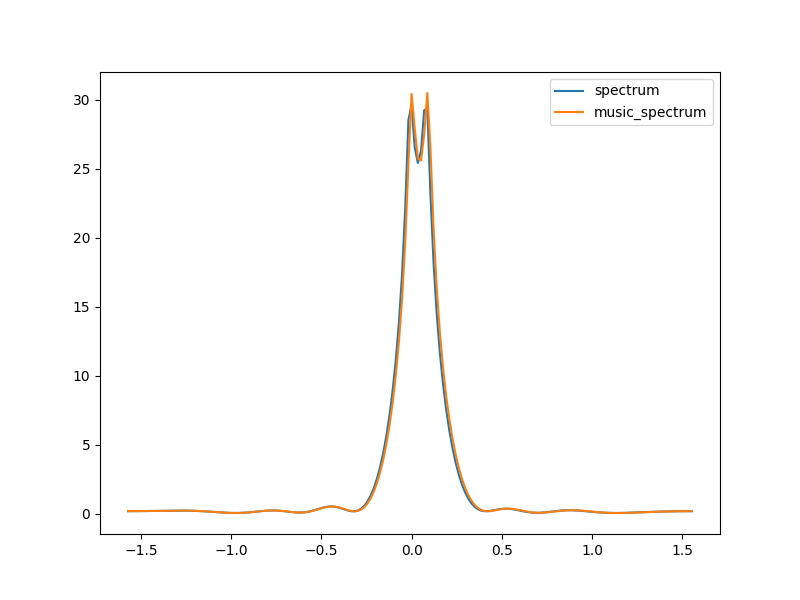

In [ ]:
array_manifold_mine = A_nominal
angles = np.linspace(-1 * np.pi / 2, np.pi / 2, 180, endpoint=False)
array_manifold = np.zeros((8, 180), dtype=complex)
noise_subspace = None
for i,angle in enumerate(angles):
    steering_vector = samples_obj.steering_vec(angle, nominal=True)
    steering_vector = steering_vector / np.linalg.norm(steering_vector)
    array_manifold[:,i] = steering_vector
array_manifold = array_manifold_mine
# Print if array_manifold_mine is equal to array_manifold
print("Are array_manifold_mine and array_manifold equal?")
print("Shape comparison:")
print(f"array_manifold_mine shape: {array_manifold_mine.shape}")
print(f"array_manifold shape: {array_manifold.shape}")
print(f"Shapes are equal: {array_manifold_mine.shape == array_manifold.shape}")

if array_manifold_mine.shape == array_manifold.shape:
    # Compare the actual values
    is_equal = np.allclose(array_manifold_mine, array_manifold, rtol=1e-10, atol=1e-10)
    print(f"Values are equal (within tolerance): {is_equal}")
    
    if not is_equal:
        # Show some statistics about the difference
        diff = np.abs(array_manifold_mine - array_manifold)
        print(f"Max difference: {np.max(diff)}")
        print(f"Mean difference: {np.mean(diff)}")
        print(f"Min difference: {np.min(diff)}")
else:
    print("Shapes are different, cannot compare values")

# Compute noise subspace if not already computed
if noise_subspace is None:
    # Perform eigenvalue decomposition
    eigenvalues, eigenvectors = np.linalg.eig(R)
    
    # Sort eigenvalues and eigenvectors in descending order
    idx = eigenvalues.argsort()[::-1]
    eigenvalues = eigenvalues[idx]
    eigenvectors = eigenvectors[:, idx]
    

    
    # Get noise subspace
    noise_subspace = eigenvectors[:, len(samples_obj.doa):]
    
# Compute MUSIC spectrum for all angles at once
# 1 / (A^H @ E_n @ E_n^H @ A) where A is (num_elements, num_angles)
E_n = noise_subspace @ np.conj(noise_subspace).T
denominator = (np.diag(array_manifold.conj().T @ E_n @ array_manifold))
spectrum = 1.0 / denominator
# spectrum = spectrum / np.max(spectrum)
# music_spectrum = music_spectrum / np.max(music_spectrum)
plt.figure(figsize=(8, 6))
plt.plot(angles, 10*np.log10(spectrum), label='spectrum')
plt.plot(angles, 10*np.log10(music_spectrum), label='music_spectrum')
# plt.plot(angles, music_spectrum - spectrum)
plt.legend()
plt.show()
